# M5A2 - Reconhecimento de Texto

Na prática de hoje vamos utilizar um modelo na tarefa de reconhecimento de texto.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [2]:
!pip install easyocr

## Introdução

Importar as bibliotecas e visualizar imagens

In [3]:
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

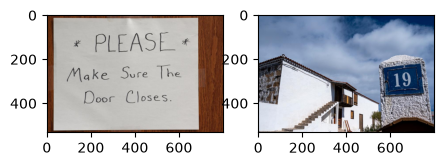

In [4]:
eng_image = Image.open("./images/eng.jpeg")
num_image = Image.open("./images/num.jpeg")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))
axes[0].imshow(eng_image)
axes[1].imshow(num_image)


## Carregar Modelo e Utilizar Modelo

In [5]:
reader = easyocr.Reader(["en"]) # Carrega o modelo de inglês para a memória.

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

['PLEASE', 'Make', 'Sure', 'The', 'Door', 'Closes.']


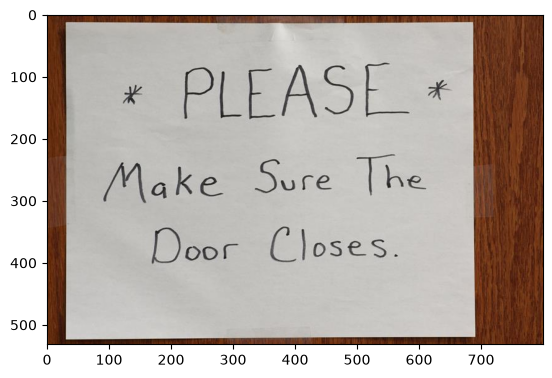

In [6]:
plt.imshow(eng_image)
result = reader.readtext("./images/eng.jpeg", detail=0)
print(result)

['19']


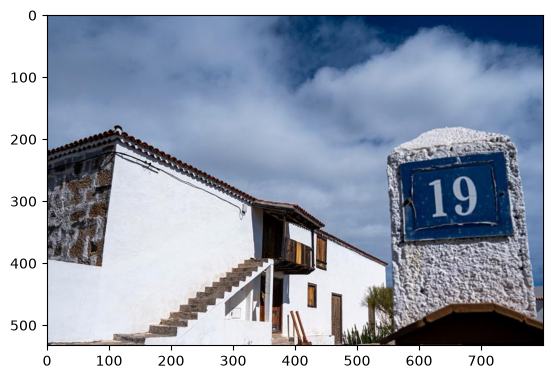

In [7]:
plt.imshow(num_image)
result = reader.readtext("./images/num.jpeg", detail=0)
print(result)

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/JaidedAI/EasyOCR
- https://www.jaided.ai/easyocr/
- https://huggingface.co
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar as imagens utilizadas nos testes.
- [ ] Altere o parâmetro `detail` para `1` e tente desenhar as informações de bounding box na imagem.

In [ ]:
eng_image1 = Image.open("./images/eng_1.jpg")
num_image1 = Image.open("./images/num_2.jpg")


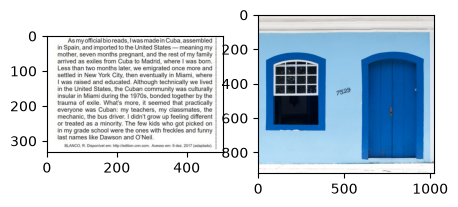

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))
axes[0].imshow(eng_image1)
axes[1].imshow(num_image1)

In [21]:
reader = easyocr.Reader(["en"]) # Carrega o modelo de inglês para a memória.

['Asmy official bioreads, Iwas madein Cuba, assembled', 'in Spain, and imported to the United States-', 'meaning my', 'mother; seven months pregnant; and the rest of my family', 'arrived as exiles from Cuba to Madrid, where', 'was born', 'Less than two months later; we emigrated once more and', 'settled in New York City; then eventually in Miami, where', 'was raised and educated. Although technically we lived', 'in the United States, the Cuban community was culturally', 'insular in Miami during the 1970s, bonded together by the', 'trauma of exile', "What's more", 'it seemed that practically', 'everyone was Cuban: my teachers, my classmates, the', 'mechanic , the bus driver:', "didn't grow up feeling different", 'treated as', 'minority:', 'few kids who got picked on', 'in my grade school were the ones with freckles and', "last names like Dawson and 0 'Neil.", 'BLANCO. R. Disponlvel em: hltp Ileditioncnn com.', 'Acerso em', 'dez 2017 (adaptado)', 'The', 'funny']


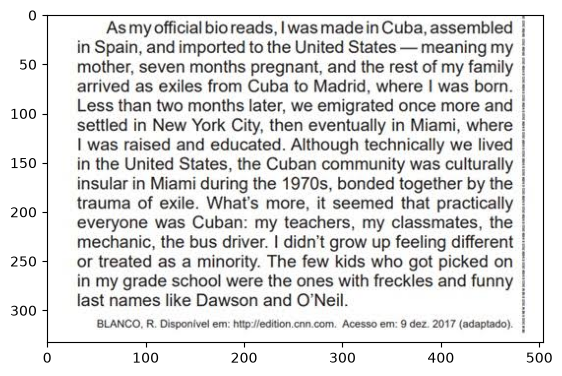

In [22]:
plt.imshow(eng_image1)
result = reader.readtext("./images/eng_1.jpg", detail=0)
print(result)

['7529']


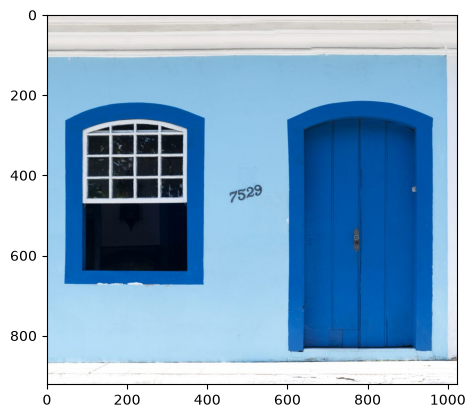

In [24]:
plt.imshow(num_image1)
result = reader.readtext("./images/num_2.jpg", detail=0)
print(result)

In [30]:
import matplotlib.patches as patches

Altere o parâmetro `detail` para `1` e tente desenhar as informações de bounding box na imagem.

In [26]:
eng_image = Image.open("./images/eng.jpeg")
num_image = Image.open("./images/num_1.jpeg")

reader = easyocr.Reader(["en"])

In [27]:
def show_ocr(image_path):
    image = Image.open(image_path)
    result = reader.readtext(image_path, detail=1)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(image)

    for (bbox, text, confidence) in result:
        (top_left, top_right, bottom_right, bottom_left) = bbox

        x = top_left[0]
        y = top_left[1]
        width = top_right[0] - top_left[0]
        height = bottom_left[1] - top_left[1]

        rect = patches.Rectangle(
            (x, y),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y - 5,
            f"{text} ({confidence:.2f})",
            color="yellow",
            fontsize=8,
            backgroundcolor="black"
        )

    plt.axis("off")
    plt.show()

    print(f"\nResultado OCR ({image_path}):")
    for _, text, conf in result:
        print(f"{text} -> {conf:.2f}")

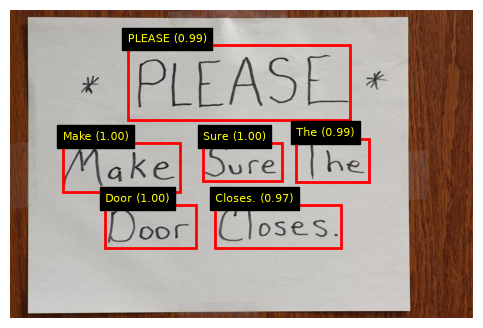


Resultado OCR (./images/eng.jpeg):
PLEASE -> 0.99
Make -> 1.00
Sure -> 1.00
The -> 0.99
Door -> 1.00
Closes. -> 0.97


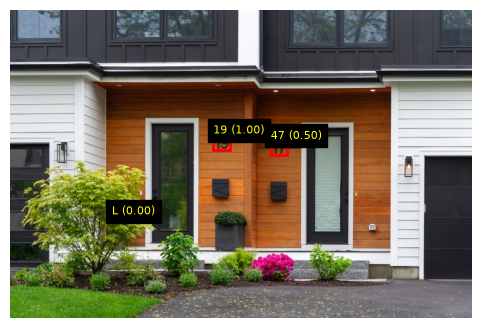


Resultado OCR (./images/num_1.jpeg):
19 -> 1.00
47 -> 0.50
L -> 0.00


In [31]:
show_ocr("./images/eng.jpeg")
show_ocr("./images/num_1.jpeg")